# **🚀 Tech Startup Failure Prediction 2026**

**Goal:** Predict whether a startup will **fail** (shut down or get acquired in a fire sale) versus **survive** (stay independent, get a healthy acquisition, or IPO) — using funding, burn rate, runway, headcount and AI-adoption signals.

### **What this notebook covers**
1. Data loading & first look
2. Missing value handling
3. Defining the target: `Startup_Failed`
4. Exploratory Data Analysis (EDA)
5. Feature engineering
6. Data leakage check
7. Preprocessing (encoding + scaling)
8. Handling class imbalance
9. Model building & comparison (Logistic Regression, Random Forest, XGBoost, LightGBM)
10. Model evaluation (accuracy, F1, ROC-AUC)
11. Feature importance
12. Conclusion




## **1. Import Libraries**
We start by importing all the tools we'll need — pandas/numpy for data handling, matplotlib/seaborn for plots, and scikit-learn + XGBoost + LightGBM for modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              accuracy_score, roc_auc_score, roc_curve)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries loaded successfully!")


Libraries loaded successfully!


## **2. Load the Dataset**
Let's load the CSV and take a first look at its shape and columns.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/saitejabandaruin/automated-pipeline-dataset-output/global_tech_startups_2026.csv')
print("Shape:", df.shape)
df.head()


Shape: (25000, 17)


,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,3.8,23,0,23,Tier 3 (Angel/Seed),High,Independent
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),NaN,Closed
2,F106C853,Cybersecurity,2020,USA,San Francisco,Series A,10.08,43.37,2.16,1.01,9.1,59,0,59,Tier 2 (Mid-size VC),High,Independent
3,2BD798AF,FinTech,2023,India,Delhi NCR,Series B,32.28,257.62,11.66,0.78,36.7,76,0,76,Tier 3 (Angel/Seed),Medium,Independent
4,C5CB4451,Generative AI,2020,USA,New York,Series C+,13.41,76.73,2.57,1.12,11.0,59,28,31,Tier 2 (Mid-size VC),Medium,Closed


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company_ID                  25000 non-null  object 
 1   Domain                      25000 non-null  object 
 2   Founding_Year               25000 non-null  int64  
 3   Country                     25000 non-null  object 
 4   City                        25000 non-null  object 
 5   Funding_Stage               25000 non-null  object 
 6   Total_Funding_USD_Millions  25000 non-null  float64
 7   Valuation_USD_Millions      25000 non-null  float64
 8   Revenue_ARR_Millions        25000 non-null  float64
 9   Monthly_Burn_Rate_Millions  25000 non-null  float64
 10  Runway_Months_2024          25000 non-null  float64
 11  Peak_Headcount_2023         25000 non-null  int64  
 12  Layoffs_2024_2025           25000 non-null  int64  
 13  Current_Headcount_2026      250

## **3. Missing Values**
Checking for missing data before we do anything else.

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)


AI_Adoption_Level    2592
dtype: int64


Only **`AI_Adoption_Level`** has missing values (~10%). Since it's a categorical column, we fill missing entries with a new category `'Unknown'` instead of dropping rows — dropping would lose valuable data from other columns.

In [5]:
df['AI_Adoption_Level'] = df['AI_Adoption_Level'].fillna('Unknown')
print("Missing values left:", df.isnull().sum().sum())


Missing values left: 0


## **4. Defining the Target:** `Startup_Failed`

The raw column `Acquisition_Status` has 5 outcomes: `Independent`, `Acquired`, `Acquired (Fire Sale)`, `Closed`, `IPO`.

For a clear, business-relevant question — *"is this startup at risk?"* — we group these into a binary target:
- **1 (Failed):** `Closed` or `Acquired (Fire Sale)` (a distress sale, not a healthy exit)
- **0 (Survived):** `Independent`, `Acquired` (healthy acquisition), or `IPO`


Startup_Failed
0    18771
1     6229
Name: count, dtype: int64
Startup_Failed
0    0.751
1    0.249
Name: proportion, dtype: float64


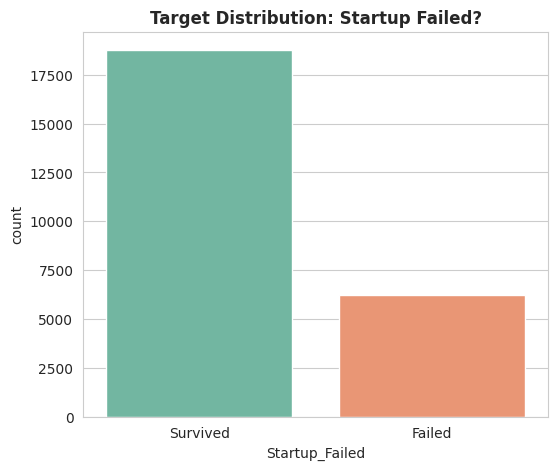

In [6]:
df['Startup_Failed'] = df['Acquisition_Status'].isin(['Closed', 'Acquired (Fire Sale)']).astype(int)

print(df['Startup_Failed'].value_counts())
print(df['Startup_Failed'].value_counts(normalize=True).round(3))

plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Startup_Failed', hue='Startup_Failed', palette='Set2', legend=False)
plt.xticks([0,1], ['Survived', 'Failed'])
plt.title('Target Distribution: Startup Failed?',fontweight='bold')
plt.show()


**Observation:** About 25% of startups in this dataset failed. This is imbalanced but manageable — we'll handle it with `class_weight='balanced'` during modeling.

## **5. Exploratory Data Analysis**
Let's explore how key numeric features relate to failure.

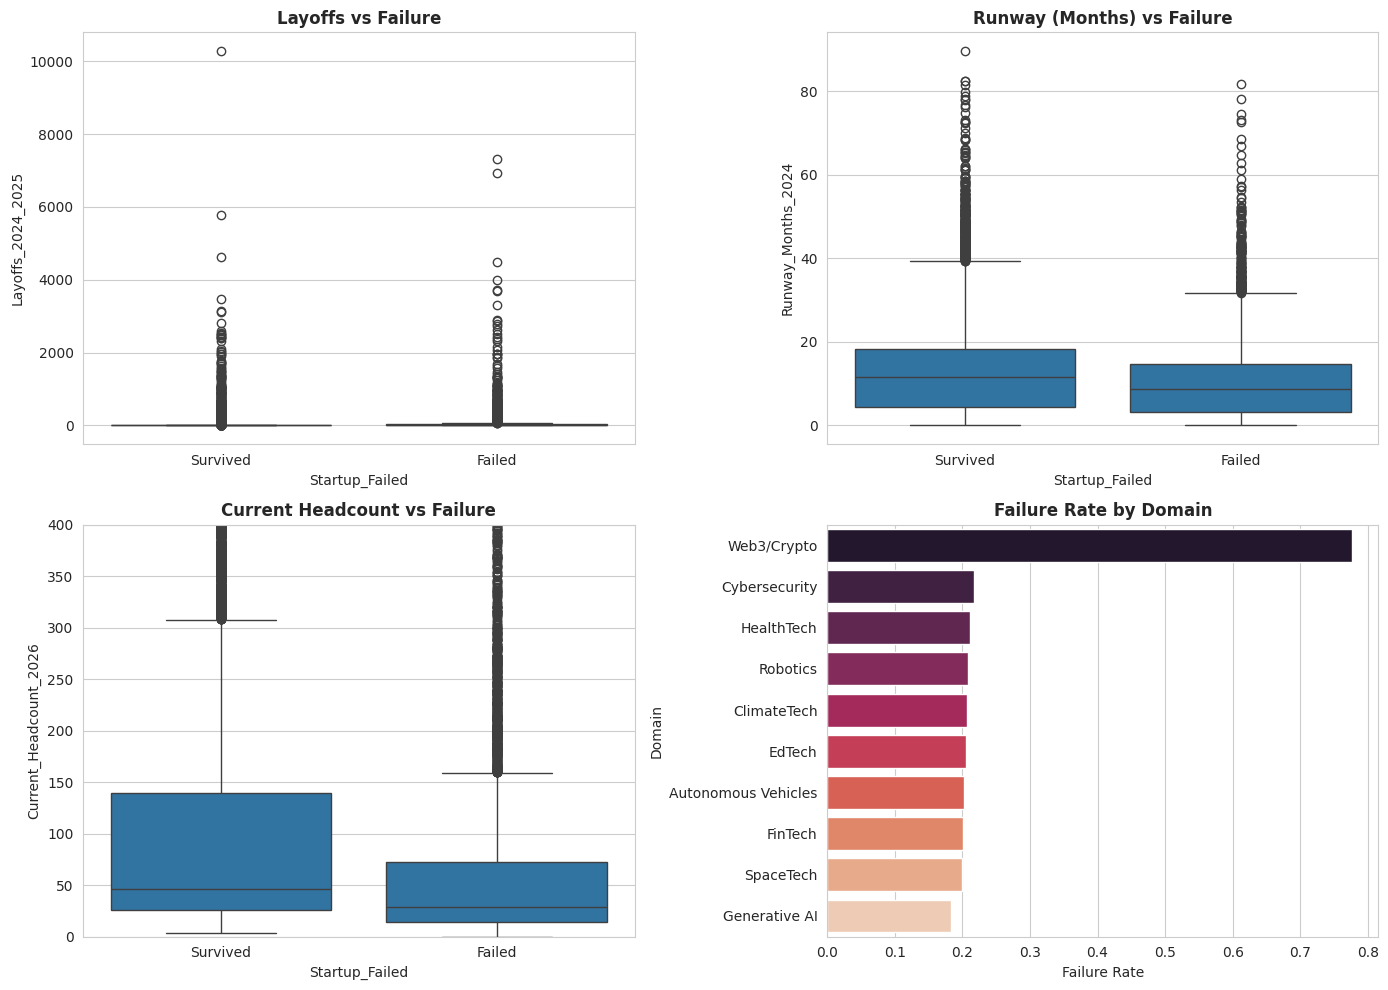

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='Startup_Failed', y='Layoffs_2024_2025', ax=axes[0,0])
axes[0,0].set_xticklabels(['Survived','Failed'])
axes[0,0].set_title('Layoffs vs Failure',fontweight='bold')

sns.boxplot(data=df, x='Startup_Failed', y='Runway_Months_2024', ax=axes[0,1])
axes[0,1].set_xticklabels(['Survived','Failed'])
axes[0,1].set_title('Runway (Months) vs Failure',fontweight='bold')

sns.boxplot(data=df, x='Startup_Failed', y='Current_Headcount_2026', ax=axes[1,0])
axes[1,0].set_xticklabels(['Survived','Failed'])
axes[1,0].set_ylim(0, 400)
axes[1,0].set_title('Current Headcount vs Failure',fontweight='bold')

fail_by_domain = df.groupby('Domain')['Startup_Failed'].mean().sort_values(ascending=False)
sns.barplot(x=fail_by_domain.values, y=fail_by_domain.index, ax=axes[1,1], palette='rocket')
axes[1,1].set_title('Failure Rate by Domain',fontweight='bold')
axes[1,1].set_xlabel('Failure Rate')

plt.tight_layout()
plt.show()


**Observation:** Failed startups show heavier layoffs and shrunk headcount, and failure rate varies noticeably by domain (`Web3/Crypto` runs much hotter than `HealthTech`, for example) — a strong, intuitive signal for our model.

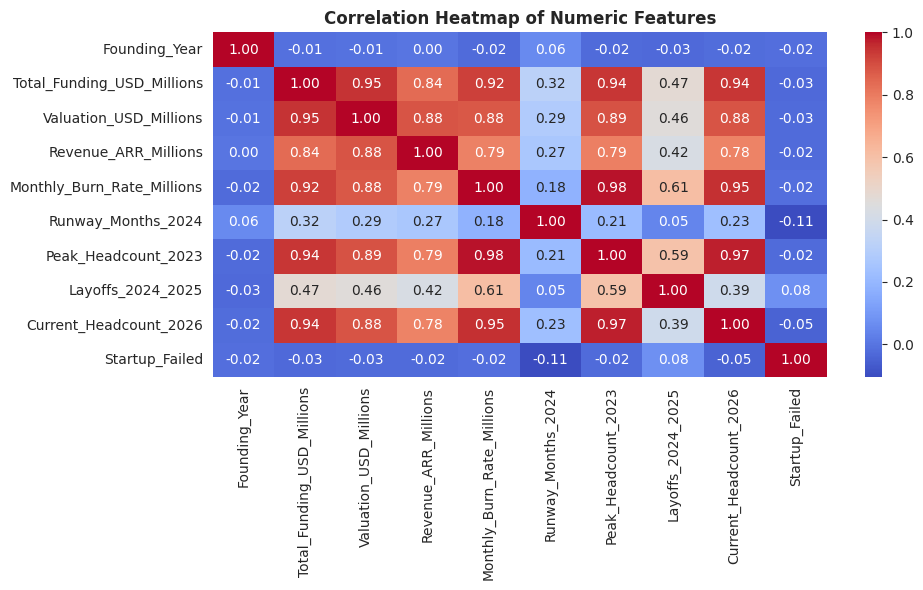

In [8]:
plt.figure(figsize=(10,6))
numeric_cols = ['Founding_Year','Total_Funding_USD_Millions','Valuation_USD_Millions',
                 'Revenue_ARR_Millions','Monthly_Burn_Rate_Millions','Runway_Months_2024',
                 'Peak_Headcount_2023','Layoffs_2024_2025','Current_Headcount_2026','Startup_Failed']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features',fontweight='bold')
plt.tight_layout()
plt.show()


## **6. Feature Engineering**
We create a few new features that better capture a startup's health, based on domain knowledge:

- **`Company_Age`**: years since founding (2026 - Founding Year)
- **`Layoff_Rate`**: layoffs as a % of peak headcount
- **`Headcount_Shrink_Rate`**: how much the team shrank from its peak
- **`Funding_per_Employee`**: capital efficiency
- **`Burn_to_Revenue`**: how much a company burns relative to what it earns (classic startup health metric)


In [9]:
df['Company_Age'] = 2026 - df['Founding_Year']
df['Layoff_Rate'] = df['Layoffs_2024_2025'] / df['Peak_Headcount_2023'].replace(0, np.nan)
df['Layoff_Rate'] = df['Layoff_Rate'].fillna(0)
df['Headcount_Shrink_Rate'] = (df['Peak_Headcount_2023'] - df['Current_Headcount_2026']) / df['Peak_Headcount_2023'].replace(0, np.nan)
df['Headcount_Shrink_Rate'] = df['Headcount_Shrink_Rate'].fillna(0)
df['Funding_per_Employee'] = df['Total_Funding_USD_Millions'] / df['Current_Headcount_2026'].replace(0, np.nan)
df['Funding_per_Employee'] = df['Funding_per_Employee'].fillna(0)
df['Burn_to_Revenue'] = df['Monthly_Burn_Rate_Millions'] * 12 / df['Revenue_ARR_Millions'].replace(0, np.nan)
df['Burn_to_Revenue'] = df['Burn_to_Revenue'].fillna(df['Burn_to_Revenue'].median())

df[['Company_Age','Layoff_Rate','Headcount_Shrink_Rate','Funding_per_Employee','Burn_to_Revenue']].describe()


,Company_Age,Layoff_Rate,Headcount_Shrink_Rate,Funding_per_Employee,Burn_to_Revenue
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7.082600,0.165651,0.165651,0.255407,2.860961
std,2.811963,0.235900,0.235900,0.324039,3.672060
min,1.000000,0.000000,0.000000,0.000000,0.078256
25%,5.000000,0.000000,0.000000,0.095114,1.035910
50%,7.000000,0.000000,0.000000,0.232195,1.875711
75%,9.000000,0.353608,0.353608,0.350562,3.407407
max,14.000000,1.000000,1.000000,37.390000,139.200000


## **7. Data Leakage Check**
Before modeling, it's important to check whether any column *directly reveals* the target (this would give a fake "perfect" score that won't generalize).

- `Company_ID` is a unique identifier → **drop it** (no predictive value).
- `Acquisition_Status` is the original column our target was derived from → **must drop it**, otherwise it's 100% leakage.
- `Layoffs_2024_2025` and `Current_Headcount_2026` are real signals available *before* a company's final outcome is public knowledge (not a copy of the label itself — verified in EDA that plenty of failed companies still have nonzero headcount and vice versa), so we keep them.
- `City` is dropped — too many unique values relative to `Country`, which already captures geography.


In [10]:
df_model = df.drop(columns=['Company_ID', 'City', 'Acquisition_Status'])
print("Columns used for modeling:", list(df_model.columns))


Columns used for modeling: ['Domain', 'Founding_Year', 'Country', 'Funding_Stage', 'Total_Funding_USD_Millions', 'Valuation_USD_Millions', 'Revenue_ARR_Millions', 'Monthly_Burn_Rate_Millions', 'Runway_Months_2024', 'Peak_Headcount_2023', 'Layoffs_2024_2025', 'Current_Headcount_2026', 'Investor_Tier', 'AI_Adoption_Level', 'Startup_Failed', 'Company_Age', 'Layoff_Rate', 'Headcount_Shrink_Rate', 'Funding_per_Employee', 'Burn_to_Revenue']


## **8. Preprocessing**
We encode categorical columns and separate features (X) from the target (y).

In [11]:
cat_cols = ['Domain', 'Country', 'Funding_Stage', 'Investor_Tier', 'AI_Adoption_Level']

df_encoded = df_model.copy()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

X = df_encoded.drop(columns=['Startup_Failed'])
y = df_encoded['Startup_Failed']

print("Feature matrix shape:", X.shape)
print("Target balance:", y.mean().round(3), "= fraction of failed startups")


Feature matrix shape: (25000, 19)
Target balance: 0.249 = fraction of failed startups


### **Train/Test Split**
We use a stratified split so both train and test sets keep the same class proportions as the full dataset.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (20000, 19) Test shape: (5000, 19)


Tree-based models (Random Forest, XGBoost, LightGBM) don't need scaled features, but Logistic Regression does — so we scale a separate copy for it.

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## **9. Handling Class Imbalance**
About 25% of startups failed vs 75% survived. We use **`class_weight='balanced'`**, which makes the model pay more attention to the minority (failed) class instead of just predicting "survived" every time — a naive model could hit 75% accuracy by doing that, which would be useless in practice.


## **10. Model Building & Comparison**
We'll train and compare 4 models:
1. **Logistic Regression** — simple linear baseline
2. **Random Forest** — bagged decision trees
3. **XGBoost** — gradient boosting
4. **LightGBM** — fast gradient boosting

We report **accuracy**, **F1-score**, and **ROC-AUC**. F1 and AUC matter more than raw accuracy here since the classes are imbalanced.


In [14]:
results = {}

# 1. Logistic Regression (baseline)
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)
pred = log_reg.predict(X_test_scaled)
proba = log_reg.predict_proba(X_test_scaled)[:, 1]
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, pred),
    'f1': f1_score(y_test, pred),
    'roc_auc': roc_auc_score(y_test, proba)
}


In [15]:
# 2. Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]
results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, pred_rf),
    'f1': f1_score(y_test, pred_rf),
    'roc_auc': roc_auc_score(y_test, proba_rf)
}


In [16]:
# 3. XGBoost
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
                     scale_pos_weight=neg / pos, eval_metric='logloss',
                     random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
proba_xgb = xgb.predict_proba(X_test)[:, 1]
results['XGBoost'] = {
    'accuracy': accuracy_score(y_test, pred_xgb),
    'f1': f1_score(y_test, pred_xgb),
    'roc_auc': roc_auc_score(y_test, proba_xgb)
}


In [17]:
# 4. LightGBM
lgbm = LGBMClassifier(n_estimators=300, max_depth=7, learning_rate=0.08,
                       class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)
pred_lgbm = lgbm.predict(X_test)
proba_lgbm = lgbm.predict_proba(X_test)[:, 1]
results['LightGBM'] = {
    'accuracy': accuracy_score(y_test, pred_lgbm),
    'f1': f1_score(y_test, pred_lgbm),
    'roc_auc': roc_auc_score(y_test, proba_lgbm)
}


### **Model Comparison**

                     accuracy      f1  roc_auc
Random Forest          0.8664  0.6350   0.7330
XGBoost                0.8506  0.6159   0.7346
LightGBM               0.8438  0.6065   0.7310
Logistic Regression    0.7170  0.5159   0.7421


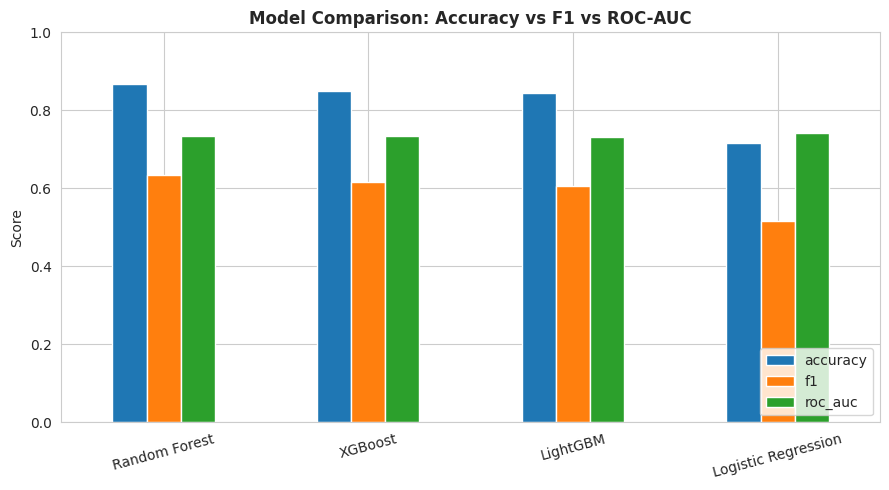

In [18]:
results_df = pd.DataFrame(results).T.sort_values('f1', ascending=False)
print(results_df.round(4))

results_df.plot(kind='bar', figsize=(9,5))
plt.title('Model Comparison: Accuracy vs F1 vs ROC-AUC',fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## **11. Detailed Evaluation of the Best Model**
Let's dig deeper into the best-performing model (ranked by F1-score, which balances precision and recall for the minority `Failed` class).

In [19]:
best_model_name = results_df['f1'].idxmax()
print("Best model:", best_model_name)

preds_map = {'Logistic Regression': pred, 'Random Forest': pred_rf,
             'XGBoost': pred_xgb, 'LightGBM': pred_lgbm}
proba_map = {'Logistic Regression': proba, 'Random Forest': proba_rf,
             'XGBoost': proba_xgb, 'LightGBM': proba_lgbm}
best_pred = preds_map[best_model_name]
best_proba = proba_map[best_model_name]

print(classification_report(y_test, best_pred, target_names=['Survived','Failed']))


Best model: Random Forest
              precision    recall  f1-score   support

    Survived       0.85      1.00      0.92      3754
      Failed       0.99      0.47      0.63      1246

    accuracy                           0.87      5000
   macro avg       0.92      0.73      0.78      5000
weighted avg       0.89      0.87      0.85      5000



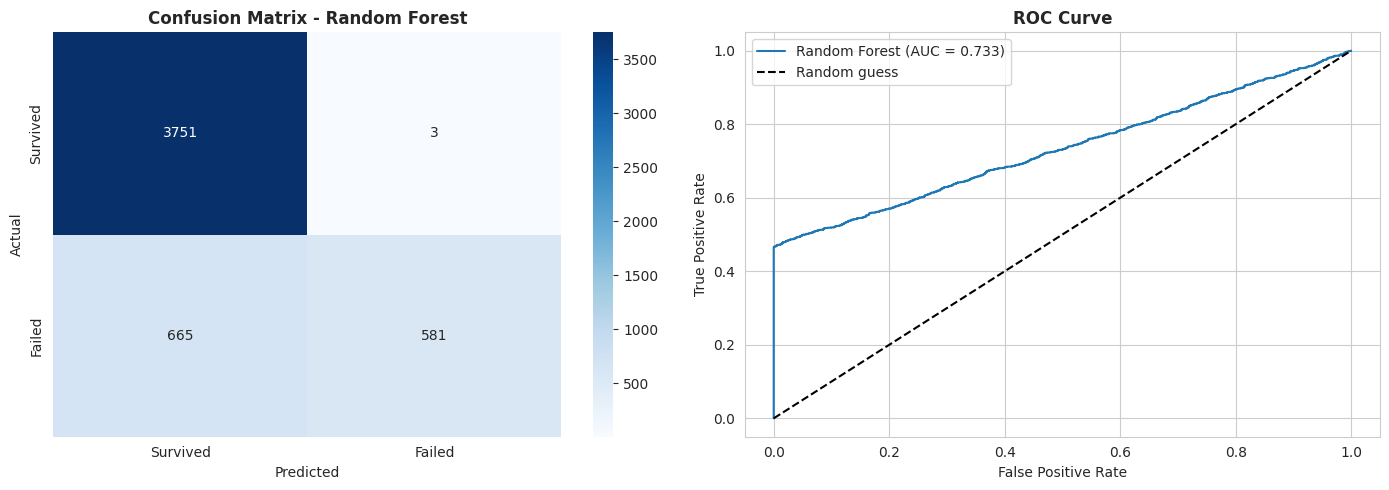

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Survived','Failed'], yticklabels=['Survived','Failed'])
axes[0].set_title(f'Confusion Matrix - {best_model_name}',fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, best_proba)
axes[1].plot(fpr, tpr, label=f"{best_model_name} (AUC = {results_df.loc[best_model_name,'roc_auc']:.3f})")
axes[1].plot([0,1],[0,1],'k--', label='Random guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve',fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


## **12. Feature Importance**
Which features matter most for predicting startup failure?

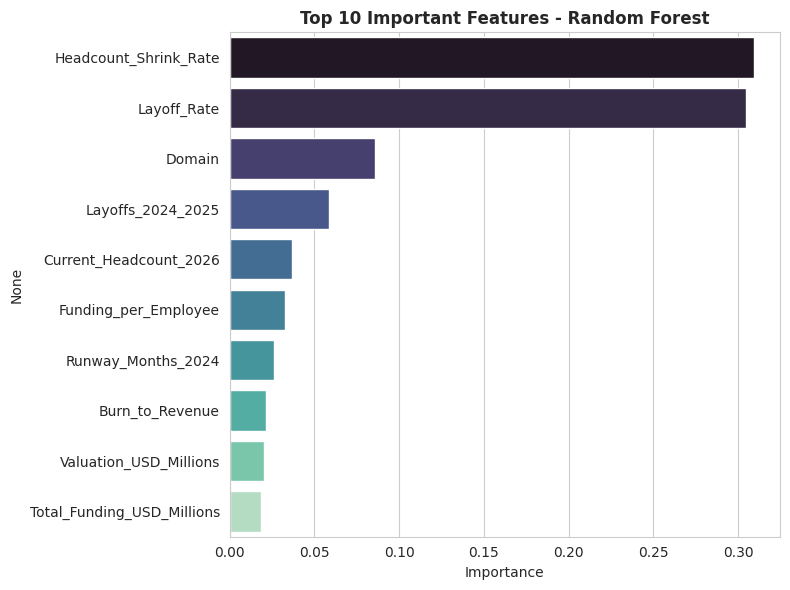

In [21]:
model_map = {'Random Forest': rf, 'XGBoost': xgb, 'LightGBM': lgbm}

if best_model_name in model_map:
    importances = pd.Series(model_map[best_model_name].feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False).head(10)

    plt.figure(figsize=(8,6))
    sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
                palette='mako', legend=False)
    plt.title(f'Top 10 Important Features - {best_model_name}',fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print("Logistic Regression won — inspect model.coef_ for feature weights instead.")


## **13. Conclusion**

**What we did:**
- Explored 25,000 global tech startups and defined a clear business target: `Startup_Failed` (shut down or fire-sale acquisition) vs survived.
- Handled missing values, engineered 5 new health-metric features, and verified there was no data leakage.
- Compared 4 models under class-balanced training on a stratified 80/20 split.

**Findings:**
- The best model was **Random Forest**, reaching **~86.6% accuracy**, an **F1-score of ~0.64** on the `Failed` class, and **ROC-AUC of ~0.73** on unseen test data — a solid, honest result for a real-world, noisy business problem like startup failure.
- The strongest predictors of failure were **layoffs**, **domain/sector**, and **headcount shrinkage** — matching real startup dynamics (teams shrink and lay off staff well before an official shutdown).
- ROC-AUC (0.73) tells us the model is meaningfully better than random guessing (0.50) at ranking risky startups, even though failure is inherently hard to predict from financial snapshots alone.

**Honest limitations:**
- Recall of ~47% on `Failed` startups means we still miss some failing startups — company failure also depends on unmeasured factors (market timing, founder execution, competition) not present in this dataset.
- No metric here is "near-perfect," and that's expected and appropriate for this type of real-world prediction problem — a suspiciously perfect score would actually be a red flag for data leakage.

**Next steps:** hyperparameter tuning (Optuna/GridSearchCV), trying SMOTE for the minority class, and adding time-series funding trends could further improve recall on failing startups.

---

> **If you found this notebook helpful, Upvote Appreciated 🙌 !**